# Zooplankton Exploratory Data Analysis

## Overview and EDA goals
This notebook performs exploratory data analysis (EDA) for the Zooplankton image dataset. The main objectives are:

- Check class balance and identify very small classes that should be handled specially.
- Inspect image sizes, aspect ratios, and area distributions to spot inconsistent crops or imaging settings.
- Show sample thumbnails per class to visually validate labels and look for artifacts or duplicates.
- Compute class-average images to observe typical object shapes and alignment.

We start be importing useful packages.

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image

In [3]:
DataPath = "../Zooplankton-Data/"

ProcessedPath = os.path.join(DataPath, "Processed Data")

sub_directories = [
    d
    for d in os.listdir(ProcessedPath)
    if os.path.isdir(os.path.join(ProcessedPath, d))
]


### Class distribution
This section counts images per class and plots the distribution. We first start by generating a table of the classes and their counts. We then plot the bar plots of these class counts for easier comparison.

In [4]:
class_counts = {}
class_counts["classes"] = []
class_counts["counts"] = []
for sub in os.listdir(ProcessedPath):
    if sub == '.DS_Store':
        continue
    SubPath = os.path.join(ProcessedPath, sub)
    all_files = [
    d for d in os.listdir(SubPath) if os.path.isfile(os.path.join(SubPath, d))
]
    class_counts["classes"].append(sub)
    class_counts["counts"].append(len(all_files))

In [5]:
pd.DataFrame(class_counts)

,classes,counts
0,Partial_Copepod,38
1,Kellicottia,31
2,Chydoridae,6
3,Phytoplankton,10
4,Trichocerca,4
5,Ceriodaphnia,2
6,Cyclopoid,180373
7,Leptodora,33
8,Brachionidae,179
9,Harpacticoid,1728


Text(0.5, 0.98, 'Class Distribution')

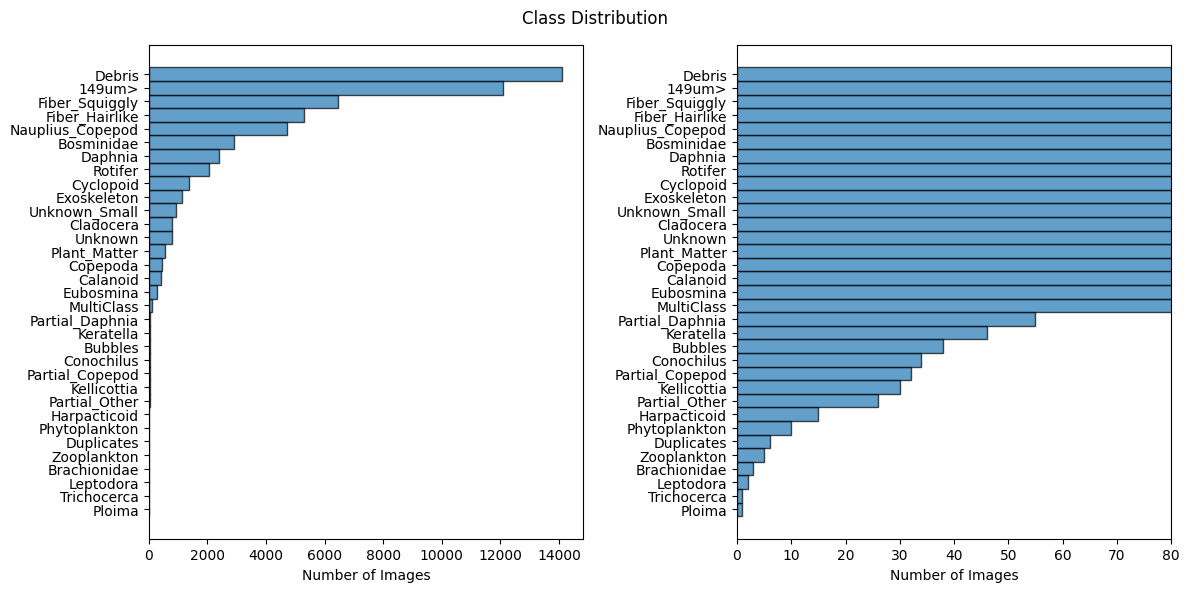

In [11]:
class_counts = pd.DataFrame(class_counts).sort_values(by="counts", ascending=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)

axs[0].barh(class_counts["classes"], class_counts["counts"], edgecolor="black", alpha=0.7, height=1)
axs[0].set_xlabel("Number of Images")

axs[1].barh(class_counts["classes"], class_counts["counts"], edgecolor="black", alpha=0.7, height=1)
axs[1].set_xlim(right=80)
axs[1].set_xlabel("Number of Images")
fig.suptitle("Class Distribution")


Text(0.5, 0.98, 'Class Distribution (Model Classes)')

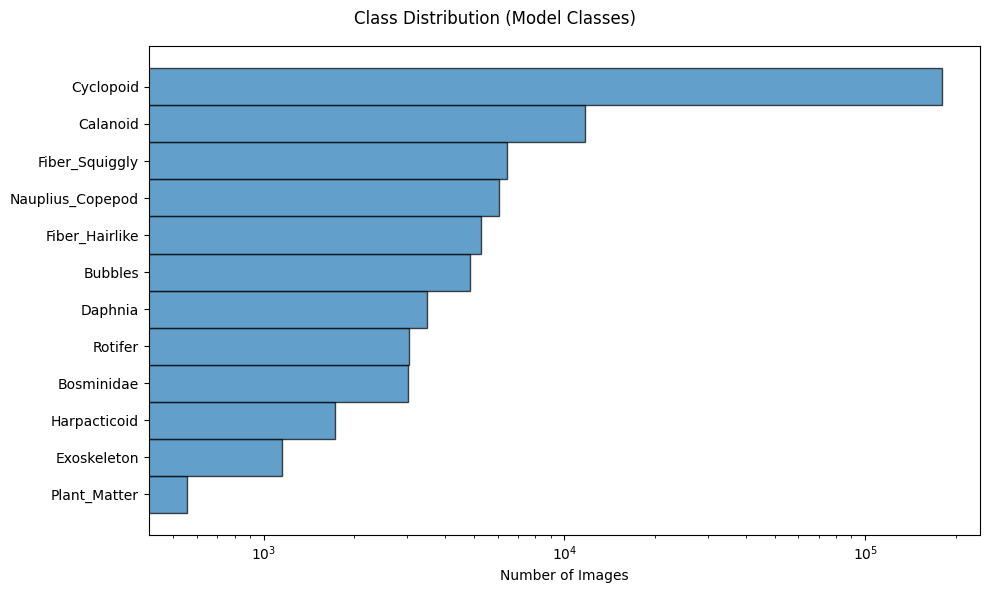

In [10]:
# Model classes
model_classes = ["Bosminidae", "Daphnia", "Calanoid", "Cyclopoid", "Harpacticoid", 
                 "Nauplius_Copepod", "Rotifer", "Bubbles", "Exoskeleton", 
                 "Fiber_Hairlike", "Fiber_Squiggly", "Plant_Matter"]

class_counts_df = pd.DataFrame(class_counts)
class_counts_df = class_counts_df[class_counts_df["classes"].isin(model_classes)].sort_values(by="counts", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6), tight_layout=True)

ax.barh(class_counts_df["classes"], class_counts_df["counts"], edgecolor="black", alpha=0.7, height=1)
ax.set_xscale('log')
ax.set_xlabel("Number of Images")
fig.suptitle("Class Distribution (Model Classes)")

As we can see there is a very large class imbalance. A few classes with very large counts (> 5000 images), while a third of the classes have less than 100 observations. This imbalance must be handled when training classifiers to ensure accurate classifications across all classes.

### Image dimensions and aspect ratios
This scatter plot shows image widths vs heights; the histogram shows aspect ratios (width/height).

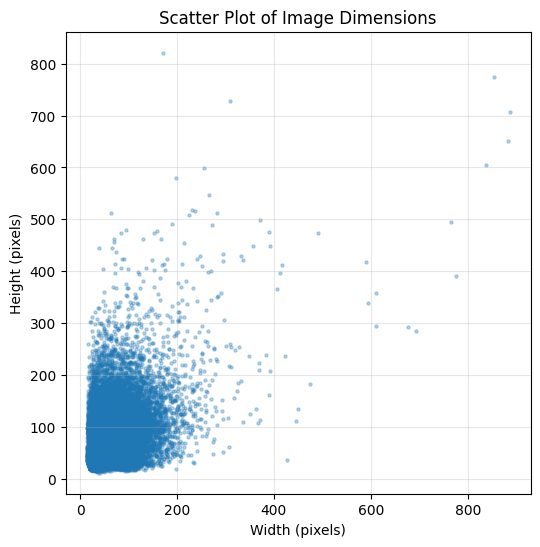

In [12]:
widths = []
heights = []

for sub in os.listdir(ProcessedPath):
    if sub.startswith("."):
        continue

    SubPath = os.path.join(ProcessedPath, sub)
    if not os.path.isdir(SubPath):
        continue

    for filename in os.listdir(SubPath):
        if filename.endswith(".tif"):
            filepath = os.path.join(SubPath, filename)
            try:
                with Image.open(filepath) as img:
                    w, h = img.size
                    widths.append(w)
                    heights.append(h)
            except Exception:
                continue

plt.figure(figsize=(6, 6))
plt.scatter(widths, heights, alpha=0.3, s=5)
plt.title("Scatter Plot of Image Dimensions")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.grid(True, alpha=0.3)
plt.show()


There is a large grouping of points within the 0-200 width and 0-400 height rectangle. However, we see the presence of extreme outlier sizes, with some observations having a height or weidth of more than 800 pixels, greatly deviating from the main cluster.

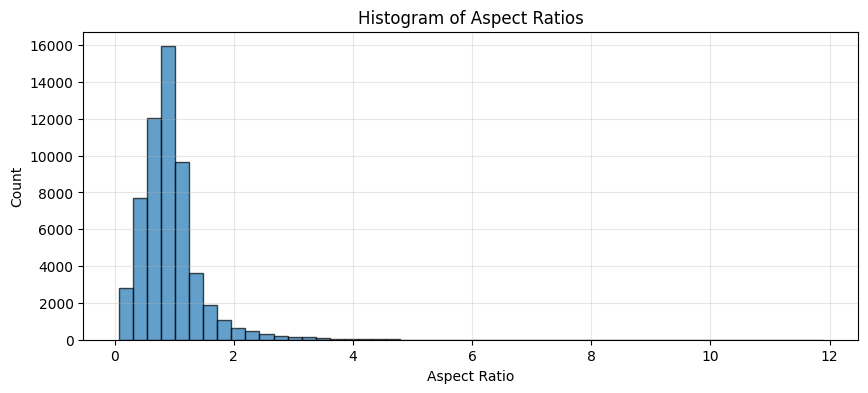

In [13]:
aspect_ratios = [w / h for w, h in zip(widths, heights)]

plt.figure(figsize=(10, 4))
plt.hist(aspect_ratios, bins=50, edgecolor="black", alpha=0.7)
plt.title("Histogram of Aspect Ratios")
plt.xlabel("Aspect Ratio")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()


This histogram echoes the results of the scatter plot. We observed a right-skewed distribution of aspect ratios, with a very large peak and concentration around 1. A very large majority of all aspect ratios are within the 0-3 range, with only a few images displaying large aspect ratios. 

Text(0.5, 0.98, 'Histograms of Picture Areas')

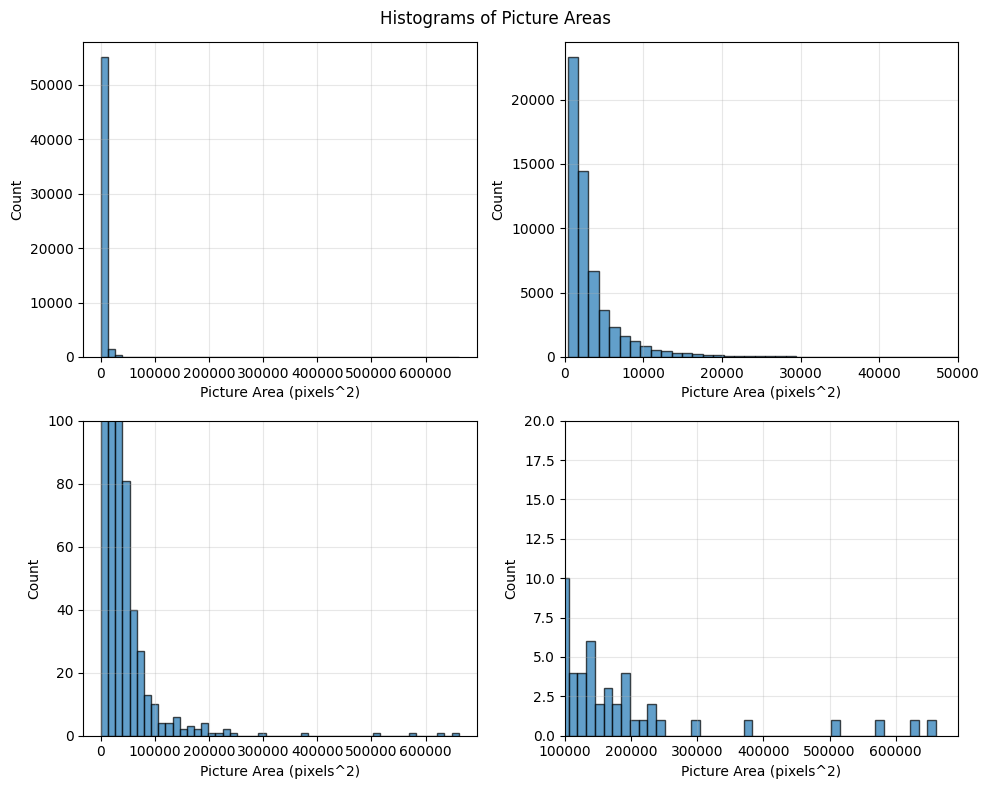

In [24]:
# Aspect Ratio Histogram
area_distribution = [w * h for w, h in zip(widths, heights)]


fig, axs = plt.subplots(2, 2, figsize=(10, 8), tight_layout=True)
axs[0,0].hist(
    area_distribution, bins=50, edgecolor="black", alpha=0.7
)
axs[0,0].set_xlabel("Picture Area (pixels^2)")
axs[0,0].set_ylabel("Count")
axs[0,0].grid(True, alpha=0.3)

axs[1,0].hist(
    area_distribution, bins=50, edgecolor="black", alpha=0.7
)
axs[1,0].set_xlabel("Picture Area (pixels^2)")
axs[1,0].set_ylabel("Count")
axs[1,0].set_ylim(top=100)
axs[1,0].grid(True, alpha=0.3)

axs[0, 1].hist(area_distribution, bins=500, edgecolor="black", alpha=0.7)
axs[0, 1].set_xlabel("Picture Area (pixels^2)")
axs[0, 1].set_ylabel("Count")
axs[0, 1].set_xlim(left = 0, right=50000)
axs[0, 1].grid(True, alpha=0.3)

axs[1, 1].hist(area_distribution, bins=50, edgecolor="black", alpha=0.7)
axs[1, 1].set_xlabel("Picture Area (pixels^2)")
axs[1, 1].set_ylabel("Count")
axs[1, 1].set_ylim(top=20)
axs[1, 1].set_xlim(left = 100000)
axs[1, 1].grid(True, alpha=0.3)

fig.suptitle('Histograms of Picture Areas')



We observe that an overwhelming majority of all images have an area below 20000. Once again, there are a few outliers images with extremely large areas, deviating from the main cluster.

These outlier observations who have been made apparent by the scatterplot and bin plots have exemplified the importance of dealing with irregular sizes. Although clustering alorithms such as CNNs natively process varying image sizes, we must be careful as methods such as padding, cropping, and rescaling distort the information available in the image.

### Visual inspection: example thumbnails per class
This grid displays three example thumbnails for each class.

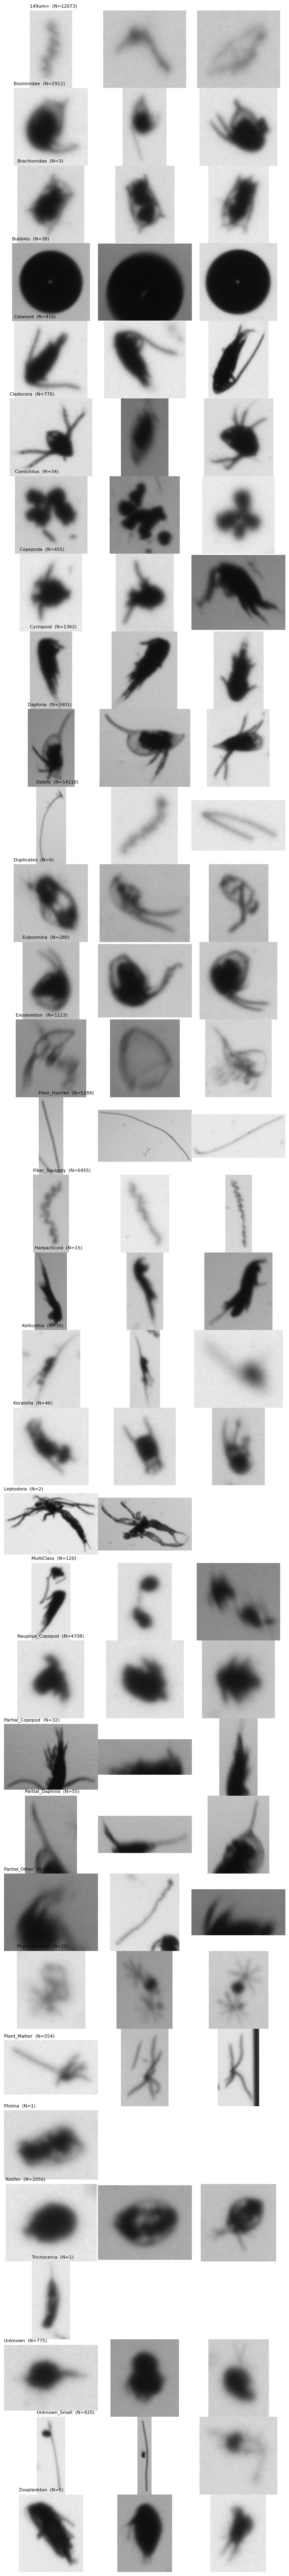

In [ ]:
classes = [
    d
    for d in sorted(os.listdir(ProcessedPath))
    if not d.startswith(".") and os.path.isdir(os.path.join(ProcessedPath, d))
]

n_cols = 3
n_rows = len(classes)
if n_rows == 0:
    raise RuntimeError("No class directories found in ProcessedPath")

fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, max(3, n_rows * 2.5)))
if n_rows == 1:
    axs = np.expand_dims(axs, 0)

for i, cls in enumerate(classes):
    SubPath = os.path.join(ProcessedPath, cls)
    files = sorted([f for f in os.listdir(SubPath) if f.lower().endswith(".tif")])
    examples = files[
        :3
    ]
    for j in range(n_cols):
        ax = axs[i, j]
        ax.axis("off")
        if j < len(examples):
            fp = os.path.join(SubPath, examples[j])
            try:
                with Image.open(fp) as im:
                    im = im.convert("RGB")
                    target_h = 200
                    w, h = im.size
                    new_w = max(1, int(w * target_h / h))
                    im_resized = im.resize((new_w, target_h), Image.BILINEAR)
                    ax.imshow(np.asarray(im_resized))
            except Exception:
                ax.text(0.5, 0.5, "error", ha="center", va="center", fontsize=8)
    axs[i, 0].set_title(f"{cls}  (N={len(files)})", loc="left", fontsize=8)

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()


The example images exemplify various features within each class. We can see that Calanoids are very round, Copepoda resemble a cluster of blobs, Harpacticoids resemble zigzags, Kellicotia have a shrimp-like structure, Conochilus have many "arms", and Nauplius Copepod have 2 distinct portions to them. We can further see the variety in images within classes, as there are no consistent aspect ratios or orientations.

### Class average images and outlier handling
The `build_average` function computes a mean image per class after padding images to a common canvas and performing a basic outlier filter (images with very different sizes are skipped).

In [ ]:
def build_average(imlist):
    N = len(imlist)
    current_h = current_w = 2
    avg_im = np.zeros((current_w, current_h, 3))
    
    sizes = np.zeros((N, 2))
    i=0
    for im in imlist:
        image = np.array(Image.open(im))
        shape = image.shape
        sizes[i, 0] = shape[0]
        sizes[i, 1] = shape[1]
        i+=1

    mean_0 = np.mean(sizes[:, 0])
    sd_0 = np.std(sizes[:, 0])
    mean_1 = np.mean(sizes[:, 1])
    sd_1 = np.std(sizes[:, 1])
    
    for im in imlist:
        image = np.array(Image.open(im))
        shape = image.shape
        h = shape[0]
        w = shape[1]
        if N == 1:
            pass
        elif np.abs((h - mean_0) / sd_0) > 1.5:
            continue
        elif np.abs((w - mean_1) / sd_1) > 1.5:
            continue
        avg_im, image, current_h = pad_d(current_h, avg_im, image, h, np.abs(h - current_h), "h")
        avg_im, image, current_w = pad_d(current_w, avg_im, image, w, np.abs(w - current_w), "w")
        avg_im += image/N
    return(avg_im, N)

def pad_d(current_d, avg_im, image, d, diff_d, dim):
    if dim == "w":
        pad = ((0, 0), (int(diff_d / 2 + 0.5), int(diff_d / 2)), (0, 0))
    else:
        pad = ((int(diff_d / 2 + 0.5), int(diff_d / 2)), (0, 0), (0, 0))
    if d > current_d:
        current_d = d
        avg_im = np.pad(avg_im, pad)
    else: 
        image = np.pad(image, pad)
               
    return avg_im, image, current_d
            
        

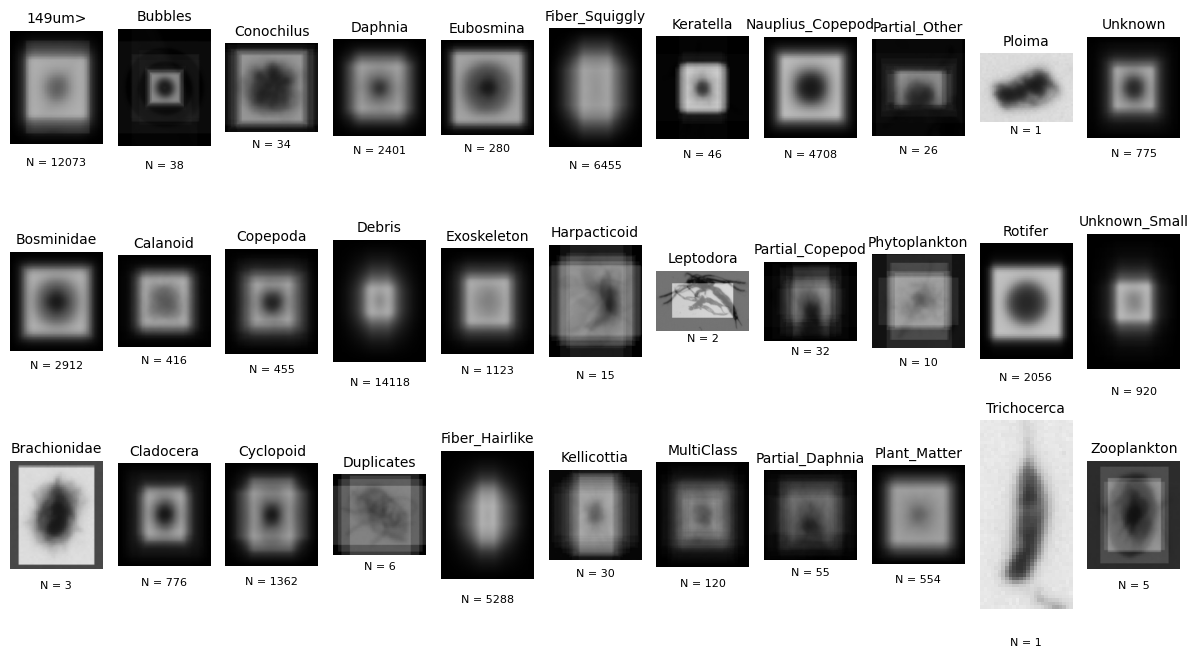

In [ ]:
fig, axs = plt.subplots(3, 11, figsize = (12, 7), tight_layout = True)

i = j = 0
subs = [d for d in os.listdir(ProcessedPath) if d != ".DS_Store"]

for sub in sorted(subs): 
    SubPath = os.path.join(ProcessedPath, sub)
    imlist = [os.path.join(SubPath, filename) for filename in os.listdir(SubPath) if filename[-4:] == ".tif"]
    
    avg_im, N = build_average(imlist)
    
    avg_im = avg_im.astype(np.uint8)
    
    axs[i, j].imshow(avg_im)
    axs[i, j].axis('off')
    axs[i, j].set_title(sub, size = 10)
    axs[i, j].text(
        0.5,
        -0.2,
        f"N = {N}",
        horizontalalignment="center",
        verticalalignment="bottom",
        transform=axs[i, j].transAxes,
        fontsize=8,
    )
    
    if i == 2:
        j += 1
        i = 0
    else:
        i += 1
plt.savefig("Class_Averages.png")

From the mean images we can see the difficulties of clustering. As most classes display no meaningful information when taking an average. In fact nearly all classes average to a uninformative ball. In a few low count classes, such as Harpacticoid or Conochilus, we can find some features. In fact within the Conochilus we can see the same cluster of balls, and for the Harpacticoids we can see a long, narrow shape, similar to what we observed within the example images.


The averages do not show any consistent background noise, eliminating the need to perform background substracting.

# Summary


## Visual Characteristics
Observed morphological features in the zooplankton include round shapes for calanoids, cluster-like blob formations for copepoda, zigzag pattenrs for harpacticoids, shrimp-like structure for kellicotia, multi-armed appearances for conochilus, and distinct two-part structures for copepods.

## Class Imabalance
We find severe class imbalance. Several classes present in the dataset have over 5000 images, while one third of the classes contain less than 100 observations.

## Image Dimensions
Due to differing sizes of the observed objects in the images there is a large amount of dimension variability. Most images fall within 0-200px by 0-400px with some outliers exceeding 800px in width or height. Similarly a majority of images contain less than 20,000 pixels with siginficant outliers containing around 650,000 pixels.

## Mean Images
Mean image analysis reveals that most class averages result in uninformative blobs, while only low-count classes such as harpacticoids and conochilus retain distinguishable features when averaged. 

## Data Quality Considerations
Each previously mentioned challenge imposes the need for a specialized training and modelling regime. Class imbalance requires specialized handling, including synthetic class padding through transformations of observations already included of the dataset, and the used of robust metrics. Image Dimension variability may require preprocessing steps to ensure important features may be learned from each observation. Finally, uninformative mean images demonstrate the need for complex models which can properly extract unique information from each class to correctly distinguish features.